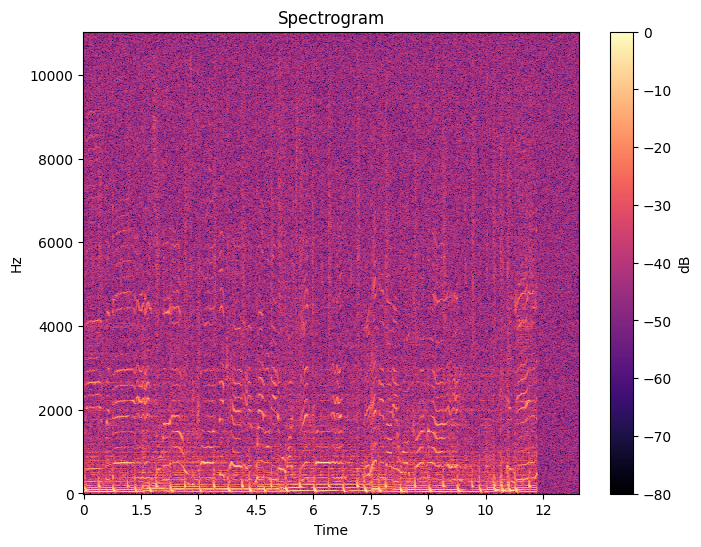

In [1]:
import scipy.io.wavfile as wavfile
import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

filename = "Coffee Cake (clip).wav"         # Channel: Mono
data, sr = librosa.load(filename)
data += np.random.normal(scale=0.09, size=len(data))
sf.write("data(noise).wav", data, sr)
D = librosa.stft(data)
plt.figure(figsize=(8, 6))

librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                         sr=sr,
                         x_axis='time',
                         y_axis='hz')
plt.colorbar(label='dB')
plt.title('Spectrogram')
plt.show()
#eps = 0.1
#data = data.astype(float)       # So that we can add same type for ufunc
#data += np.random.normal(scale=eps, size=len(data))
#new_filename = filename.removesuffix(".wav") + "-transformed.wav"   # Edit the name of the file
#wavfile.write(new_filename, sr, data)   # I'm leaving this here because I don't know the code for writing out an audio file using librosa

(558,)


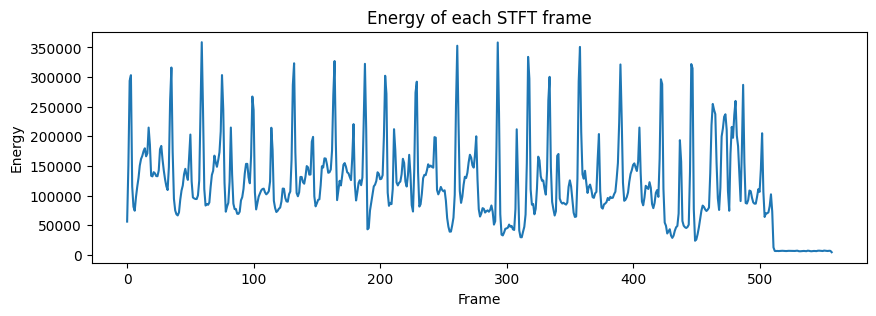

In [2]:
frame_energy = np.sum(np.abs(D)**2, axis=0)
print(frame_energy.shape)
plt.figure(figsize=(10, 3))
plt.plot(frame_energy)
plt.xlabel("Frame")
plt.ylabel("Energy")
plt.title("Energy of each STFT frame")
plt.show()

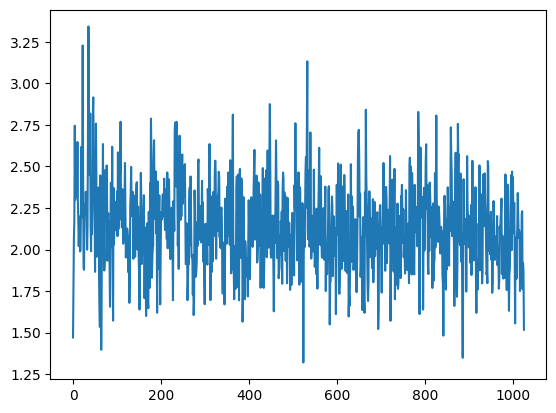

In [3]:
num_frames = len(frame_energy)
num_quiet = int(0.1 * num_frames)
quiet_frames = np.argsort(frame_energy)[:num_quiet]
quiet_stft = D[:, quiet_frames]
noise_profile = np.median(np.abs(quiet_stft), axis=1)
plt.plot(noise_profile)
plt.show()
#noise_profile.shape
#print(noise_profile[:20])

In [4]:
"""mask = np.abs(D) > 2 * noise_profile[:, None]
print(mask.shape)
print(mask.dtype)
D_filtered = D * mask""""Coffee Cake (clip).wav"

magnitude = np.abs(D)
snr = magnitude / noise_profile[:, None]
snr

array([[ 6.552578  ,  0.2722214 ,  4.331386  , ...,  1.2077383 ,
         0.34616572,  0.54536027],
       [ 6.487943  ,  9.148455  ,  6.814458  , ...,  1.1013985 ,
         1.13078   ,  0.7829359 ],
       [10.50255   ,  4.640457  ,  7.1352143 , ...,  0.5038731 ,
         1.0117592 ,  0.9819591 ],
       ...,
       [ 0.49202856,  0.40891978,  0.91407347, ...,  0.914184  ,
         0.8444699 ,  1.315562  ],
       [ 0.38756797,  1.2912283 ,  1.3738831 , ...,  0.29996505,
         1.2575581 ,  2.116016  ],
       [ 0.41553855,  1.9362043 ,  2.2756844 , ...,  0.37670627,
         1.7006932 ,  2.969883  ]], shape=(1025, 558), dtype=float32)

In [5]:
def piecewise_gain(
        magnitude,
        noise_profile,
        lower_ratio=1.0,
        upper_ratio=5.0,
        epsilon=1e-10
):
    ratio = magnitude / (noise_profile[:, None] + epsilon)
    normalized = (ratio - lower_ratio) / (upper_ratio - lower_ratio)
    gain = np.clip(normalized, 0, 1)
    return gain

In [6]:
D_filtered = D * piecewise_gain(magnitude=magnitude, noise_profile=noise_profile)
denoised = librosa.istft(D_filtered)
sf.write('denoise.wav', denoised, sr)